# Day 1 : DES
### Learning about Discrete Event simulation, and experimenting with a Shovel Dumper setup
Following is the original code copy pasted:

In [23]:
import simpy
import random
import pandas as pd

RANDOM_SEED = 42
SIM_TIME = 8 * 60  # minutes in one 8-hour shift
N_TRUCKS = 3
SHOVEL_CAPACITY = 1

random.seed(RANDOM_SEED)

records = []

def truck_cycle(env, truck_id, shovel):
    """A simple truck cycle: request shovel, load, travel loaded, dump, return."""

    cycle = 0

    while env.now < SIM_TIME:

        cycle += 1

        arrival_time = env.now

        with shovel.request() as request:

            yield request

            queue_time = env.now - arrival_time

            loading_time = random.uniform(4, 8)
            yield env.timeout(loading_time)

        loaded_travel = random.uniform(10, 18)
        yield env.timeout(loaded_travel)

        dumping_time = random.uniform(2, 4)
        yield env.timeout(dumping_time)

        empty_return = random.uniform(8, 14)
        yield env.timeout(empty_return)

        records.append({
            "truck_id": truck_id,
            "cycle": cycle,
            "finish_time": env.now,
            "queue_time": queue_time,
            "loading_time": loading_time,
            "loaded_travel": loaded_travel,
            "dumping_time": dumping_time,
            "empty_return": empty_return,
            "cycle_time": env.now - arrival_time
        })

# Create and run environment
env = simpy.Environment()

shovel = simpy.Resource(env, capacity=SHOVEL_CAPACITY)

for i in range(N_TRUCKS):
    env.process(truck_cycle(env, f"Truck_{i+1}", shovel))

env.run(until=SIM_TIME)

df = pd.DataFrame(records)

print(df.head())

print("Total completed cycles:", len(df))

print("Average cycle time:",
      round(df["cycle_time"].mean(), 2),
      "minutes")

print("Average queue time:",
      round(df["queue_time"].mean(), 2),
      "minutes")

  truck_id  cycle  finish_time  queue_time  loading_time  loaded_travel  \
0  Truck_1      1    28.632825    0.000000      6.557707      10.200086   
1  Truck_2      1    34.466137    6.557707      5.100117      11.785686   
2  Truck_3      1    50.038128   11.657824      6.945885      17.137437   
3  Truck_1      2    61.526695    0.000000      4.874552      14.042842   
4  Truck_2      2    67.779726    0.000000      4.106144      14.359532   

   dumping_time  empty_return  cycle_time  
0      3.353399      8.521633   28.632825  
1      2.843844      8.178783   34.466137  
2      2.397675     11.899307   50.038128  
3      2.440881     11.535594   32.893870  
4      2.012998     12.834916   33.313589  
Total completed cycles: 41
Average cycle time: 34.46 minutes
Average queue time: 0.85 minutes


# Finding the optimal number of Trucks
 We run a loop on truck numbers from 1 to 8. Total no. of cycles serves as the primary KPI of the simulation

In [28]:
import simpy
import random
import pandas as pd

# Simulation Parameters
RANDOM_SEED = 42
SIM_TIME = 8 * 60          # 8-hour shift in minutes
SHOVEL_CAPACITY = 1

random.seed(RANDOM_SEED)

# Truck Cycle Process

def truck_cycle(env, truck_id, shovel, records):

    cycle = 0

    #Running loop until sim time reached
    while env.now < SIM_TIME:

        cycle += 1
        # In one cycle, truck arrives at shovel, requests shovel as resource, and waits until its available, queue time is noted.
        #Truck is loaded, loading time is generated randomly in range(4,8)
        #Truck travels, loaded_travel time is noted.
        #Truck dumps, dumping time noted
        #Empty truck returns to shovel, empty_return time noted. 
        # truck_id, cycle_time, and queue_time stored as dictionary in list records. 
        arrival_time = env.now

        # Request shovel resource
        with shovel.request() as request:

            yield request

            # Waiting time in queue
            queue_time = env.now - arrival_time

            # Loading operation
            loading_time = random.uniform(4, 8)
            yield env.timeout(loading_time)

        # Loaded travel
        loaded_travel = random.uniform(10, 18)
        yield env.timeout(loaded_travel)

        # Dumping
        dumping_time = random.uniform(2, 4)
        yield env.timeout(dumping_time)

        # Empty return
        empty_return = random.uniform(8, 14)
        yield env.timeout(empty_return)

        # Store cycle data
        records.append({
            "truck_id": truck_id,
            "cycle_time": env.now - arrival_time,
            "queue_time": queue_time
        })

#List init
results = []


# Run Simulation for
# Truck Counts 1 to 8


for N_TRUCKS in range(1, 9):

    # Reset storage for each simulation
    records = []

    # Create simulation environment
    env = simpy.Environment()

    # Create shovel resource
    shovel = simpy.Resource(env, capacity=SHOVEL_CAPACITY)

    # Spawn trucks
    for i in range(N_TRUCKS):

        env.process(
            truck_cycle(
                env,
                f"Truck_{i+1}",
                shovel,
                records
            )
        )

    # Run simulation
    env.run(until=SIM_TIME)

    # Convert cycle records to dataframe
    df = pd.DataFrame(records)

    # Store KPIs
    results.append({

        "n_trucks": N_TRUCKS,

        "total_cycles": len(df),

        "avg_cycle_time": df["cycle_time"].mean(),

        "avg_queue_time": df["queue_time"].mean()

    })


# Final KPI Dataframe

results_df = pd.DataFrame(results)

print(results_df)

   n_trucks  total_cycles  avg_cycle_time  avg_queue_time
0         1            14       32.857234        0.000000
1         2            28       34.160386        0.267944
2         3            39       35.940790        1.426798
3         4            52       35.794065        1.808083
4         5            61       37.531656        3.268219
5         6            71       38.973699        4.735227
6         7            76       42.730085        8.893068
7         8            72       50.040603       15.826406


### We got total_cycles, avg_cycle_time and avg_queue_time for n=1 to 8 trucks. 
### Total transported volume is proportional to total completed cycles. 
### Below are kpi plots:

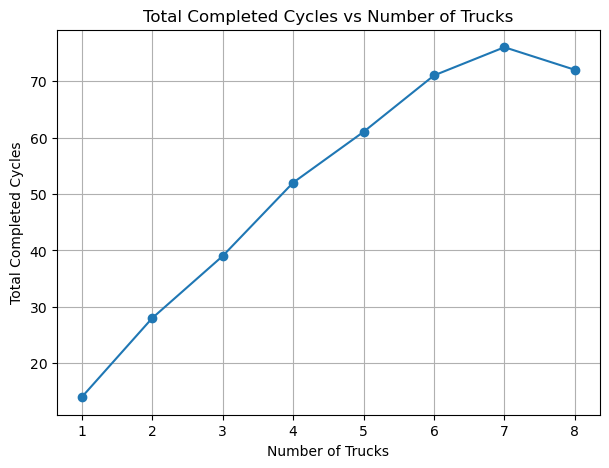

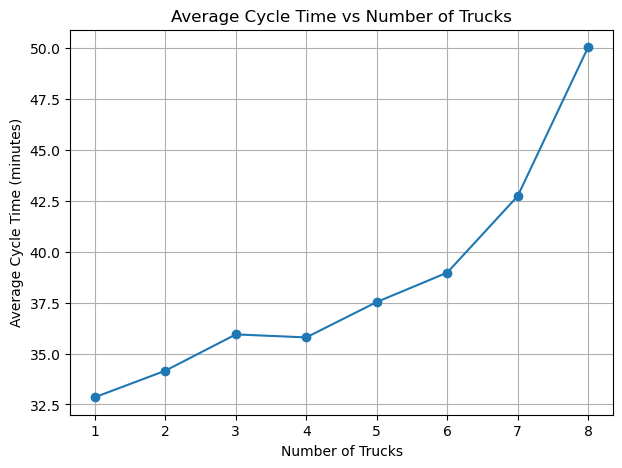

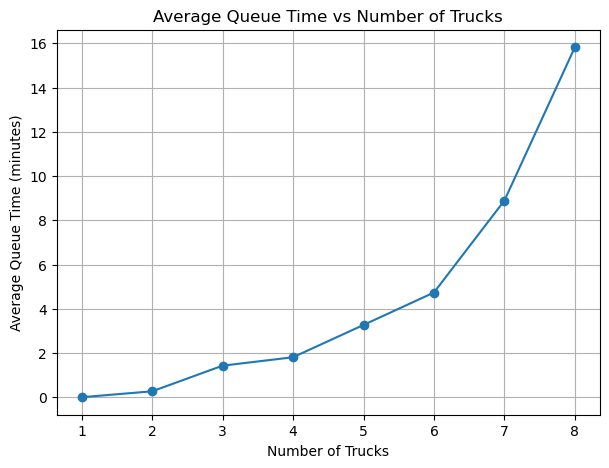

In [30]:
import matplotlib.pyplot as plt

# Plot: Total Completed Cycles
plt.figure(figsize=(7,5))
plt.plot(
    results_df["n_trucks"],
    results_df["total_cycles"],
    marker='o'
)

plt.xlabel("Number of Trucks")
plt.ylabel("Total Completed Cycles")
plt.title("Total Completed Cycles vs Number of Trucks")
plt.grid(True)
plt.show()


# Plot: Average Cycle Time
plt.figure(figsize=(7,5))
plt.plot(
    results_df["n_trucks"],
    results_df["avg_cycle_time"],
    marker='o'
)

plt.xlabel("Number of Trucks")
plt.ylabel("Average Cycle Time (minutes)")
plt.title("Average Cycle Time vs Number of Trucks")
plt.grid(True)
plt.show()


# Plot: Average Queue Time
plt.figure(figsize=(7,5))
plt.plot(
    results_df["n_trucks"],
    results_df["avg_queue_time"],
    marker='o'
)

plt.xlabel("Number of Trucks")
plt.ylabel("Average Queue Time (minutes)")
plt.title("Average Queue Time vs Number of Trucks")
plt.grid(True)
plt.show()

 From the above data, it is evident that increasing the number of trucks increases the total number of cycles upto n=7, but drops ahead of it. The reason of this behavior is jams. at n>=8, the avg Queue time jumps significantly, indicating a traffic jam. 